In [1]:
!python --version

Python 3.10.11


In [2]:
import cupy; cupy.show_config()

OS                           : Windows-10-10.0.26200-SP0
Python Version               : 3.10.11
CuPy Version                 : 13.6.0
CuPy Platform                : NVIDIA CUDA
NumPy Version                : 2.2.6
SciPy Version                : 1.15.3
Cython Build Version         : 3.0.12
Cython Runtime Version       : None
CUDA Root                    : C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1
nvcc PATH                    : C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1\bin\nvcc.EXE
CUDA Build Version           : 13000
CUDA Driver Version          : 13010
CUDA Runtime Version         : 13000 (linked to CuPy) / 13010 (locally installed)
CUDA Extra Include Dirs      : []
cuBLAS Version               : (available)
cuFFT Version                : 12100
cuRAND Version               : 10401
cuSOLVER Version             : (12, 0, 9)
cuSPARSE Version             : (available)
NVRTC Version                : (13, 1)
Thrust Version               : 200800
CUB Build Versio

In [4]:
# Configure logging to see pipeline output
import logging

logging.basicConfig(
    
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True 
)

In [2]:
import ome_types, requests
response = requests.get("https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/OME/METADATA.ome.xml")
data = response.text
ome_xml = ome_types.from_xml(response.text.replace("Â",""))
channel_names = [(i, c.name) for i, c in enumerate(ome_xml.images[0].pixels.channels)]
channel_names

unique_channels = {}
for i, name in channel_names:
    if name not in unique_channels.values() and 'do not use' not in name:
        unique_channels[i] = name
print(unique_channels)

{0: 'Hoechst', 1: "5'hmC", 2: 'MX1', 3: 'MART1', 6: 'MHC-I', 7: 'SOX10', 9: 'S100B', 10: 'MITF', 13: 'pan-cytokeratin', 14: 'lamin-ABC', 15: 'PDL1', 18: 'S100A', 19: 'CD31', 21: 'CD206', 22: 'pMLC2', 25: 'CD4', 26: 'LAG3', 27: 'CD20', 29: 'PRAME', 30: 'CD163', 31: 'IRF1', 33: 'B-catenin', 34: 'CD3E', 35: 'CD8a', 37: 'CD11b', 38: 'FOXP3', 39: 'PD1', 41: 'Ki67', 42: 'CD11c', 43: 'COX-IV', 45: 'LysozymeC', 46: 'SOX9', 47: 'PMEL', 48: 'CD103', 50: 'CyclinD1', 51: 'BAF1', 53: 'B-actin', 54: 'Mast cell tryptase', 55: 'CD15', 56: 'Podoplanin', 58: 'B-tubulin', 59: 'Catalase', 60: 'y-H2AX', 62: 'E-cadherin', 63: 'Vimentin', 65: 'GranzymeB', 67: 'MHC-II', 68: 'H3K27me3', 69: 'Collagen (SHG)'}


In [ ]:
from bioset_preprocessing import Pipeline, Config 

config = Config(
    zarr_url="https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/0",
    metadata_url="https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/OME/METADATA.ome.xml",
    max_num_channels_in_comb=4,          
    enrichment_threshold=2.0,            
    tile_size=256,
    zarr_component="0",
    threshold_method="otsu",
    output_dir="./test_results_all",
    cc_filter_enabled=True,
    cc_min_volume_um3=0.8,
    dilation_radii_um=[0,1,2,3,4,5],
    hierarchy_levels=3 #0,1,2,3
)
pipeline = Pipeline(config)
results = pipeline.run()

2026-02-07 15:28:12,098 - bioset_preprocessing.data.metadata - INFO - Loading metadata from https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/OME/METADATA.ome.xml
2026-02-07 15:28:12,300 - bioset_preprocessing.data.metadata - INFO - Loaded metadata: 70 channels, PhysicalDimensions(x=0.13999999999999999μm, y=0.14μm, z=0.28μm)
2026-02-07 15:28:12,303 - bioset_preprocessing.pipeline - INFO - Loading data...
2026-02-07 15:28:12,303 - bioset_preprocessing.data.loader - INFO - Loading Zarr from: https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/0
2026-02-07 15:28:12,303 - bioset_preprocessing.data.loader - INFO - Resolution level: 0
2026-02-07 15:28:12,621 - bioset_preprocessing.data.loader - INFO - Loaded array: (1, 70, 194, 5508, 10908), dtype=>u2
2026-02-07 15:28:12,621 - bioset_preprocessing.data.loader - INFO - Dimensions: T=1, C=70, Z=194, Y=5508, X=10908
2026-02-07 15:28:12,621 - bios

In [3]:
results["profiling"]["stage_summary"]

{'cc_filter': {'total_s': 357.8098,
  'mean_s': 0.3782,
  'std_s': 0.2594,
  'min_s': 0.0084,
  'max_s': 1.1194,
  'pct_of_total': 8.5521},
 'dilation': {'total_s': 19.223,
  'mean_s': 0.0203,
  'std_s': 0.0146,
  'min_s': 0.0,
  'max_s': 0.0436,
  'pct_of_total': 0.4595},
 'distance_transform': {'total_s': 104.8078,
  'mean_s': 0.1108,
  'std_s': 0.0775,
  'min_s': 0.0028,
  'max_s': 0.2771,
  'pct_of_total': 2.505},
 'hierarchy': {'total_s': 0.0638,
  'mean_s': 0.0,
  'std_s': 0.0,
  'min_s': 0.0,
  'max_s': 0.0,
  'pct_of_total': 0.0015},
 'intensity_stats': {'total_s': 30.4494,
  'mean_s': 0.0322,
  'std_s': 0.0048,
  'min_s': 0.0098,
  'max_s': 0.0461,
  'pct_of_total': 0.7278},
 'load': {'total_s': 3413.6318,
  'mean_s': 3.6085,
  'std_s': 1.5423,
  'min_s': 1.4137,
  'max_s': 13.4863,
  'pct_of_total': 81.59},
 'overlap': {'total_s': 140.2894,
  'mean_s': 0.1483,
  'std_s': 0.0191,
  'min_s': 0.0464,
  'max_s': 0.1873,
  'pct_of_total': 3.3531},
 'threshold': {'total_s': 105.924

In [14]:
import tifffile as tiff
import dask.array as da
import zarr
import requests
import io
from ome_zarr.io import parse_url

path = "https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/0"
root = parse_url(path, mode="w")
store = root.store
daskArray = da.from_zarr(store, component="0") # t=0, high-res
daskArray



dask.array<from-zarr, shape=(1, 70, 194, 5508, 10908), dtype=>u2, chunksize=(1, 1, 1, 1024, 1024), chunktype=numpy.ndarray>

In [114]:
channel = 7
x_start = 8064
y_start = 0
x_end = 9408
y_end = 1344

tiff.imwrite(f"{channel}_{x_start}_{x_end}_{y_start}_{y_end}.tiff", daskArray[0,channel,:,y_start:y_end, x_start:x_end].compute())

In [ ]:
import ome_types, requests
response = requests.get("https://lsp-public-data.s3.amazonaws.com/biomedvis-challenge-2025/Dataset1-LSP13626-melanoma-in-situ/OME/METADATA.ome.xml")
data = response.text
ome_xml = ome_types.from_xml(response.text.replace("Â",""))
channel_names = [(i, c.name) for i, c in enumerate(ome_xml.images[0].pixels.channels)]
channel_names

AttributeError: 'list' object has no attribute 'unique'

In [4]:
ome_xml.images[0].pixels.physical_size_x, ome_xml.images[0].pixels.physical_size_y, ome_xml.images[0].pixels.physical_size_z

(0.13999999999999999, 0.14, 0.28)

In [5]:
ome_xml.images[0].pixels.physical_size_x_unit, ome_xml.images[0].pixels.physical_size_y_unit, ome_xml.images[0].pixels.physical_size_z_unit

(<UnitsLength.MICROMETER: 'µm'>,
 <UnitsLength.MICROMETER: 'µm'>,
 <UnitsLength.MICROMETER: 'µm'>)

In [125]:
import numpy as np
from scipy.ndimage import distance_transform_edt
import tifffile

# === PARAMETERS ===
input_path = "mask_cleaned.tif"
output_path = "7_dilated.tiff"
radius_um = 1.0  # Dilation radius in micrometers

# Physical voxel spacing (Z, Y, X) in micrometers
spacing_um = (0.28, 0.14, 0.14)

# === LOAD ===
mask = tifffile.imread(input_path)
print(f"Loaded: {mask.shape}, dtype={mask.dtype}, unique values: {np.unique(mask)}")

# Ensure binary (0 or 1)
mask_binary = (mask > 0).astype(np.uint8)

# === DISTANCE TRANSFORM ===
# distance_transform_edt computes distance from background (0) to nearest foreground (1)
# We want distance from foreground, so invert the mask
distances = distance_transform_edt(mask_binary == 0, sampling=spacing_um)
print(f"Distance range: {distances.min():.2f} to {distances.max():.2f} μm")

# === DILATE ===
# Dilated mask = original mask OR anywhere within radius_um of original mask
dilated = (distances <= radius_um) | (mask_binary > 0)
dilated = (dilated * 255).astype(np.uint8)

print(f"Original active voxels: {np.sum(mask_binary > 0):,}")
print(f"Dilated active voxels: {np.sum(dilated > 0):,}")
print(f"Expansion factor: {np.sum(dilated > 0) / np.sum(mask_binary > 0):.2f}x")

# === SAVE ===
tifffile.imwrite(output_path, dilated, compression='zlib')
print(f"Saved: {output_path}")

Loaded: (194, 1344, 1344), dtype=uint8, unique values: [  0 255]
Distance range: 0.00 to 46.90 μm
Original active voxels: 11,987,890
Dilated active voxels: 47,235,628
Expansion factor: 3.94x
Saved: 7_dilated.tiff


Loaded: (194, 1344, 1344), dtype=uint16

DETECTION RESULTS

--- PEAKS ---
  Peak 1: intensity = 288

--- MINIMA BETWEEN CONSECUTIVE PEAKS ---
  No minima between peaks (need at least 2 peaks)

--- KNEE/SHOULDER AFTER LAST PEAK ---
  Knee: intensity = 5947

--- BETWEEN LAST PEAK AND KNEE ---
  Minimum: intensity = 5947
  Midpoint: intensity = 3117


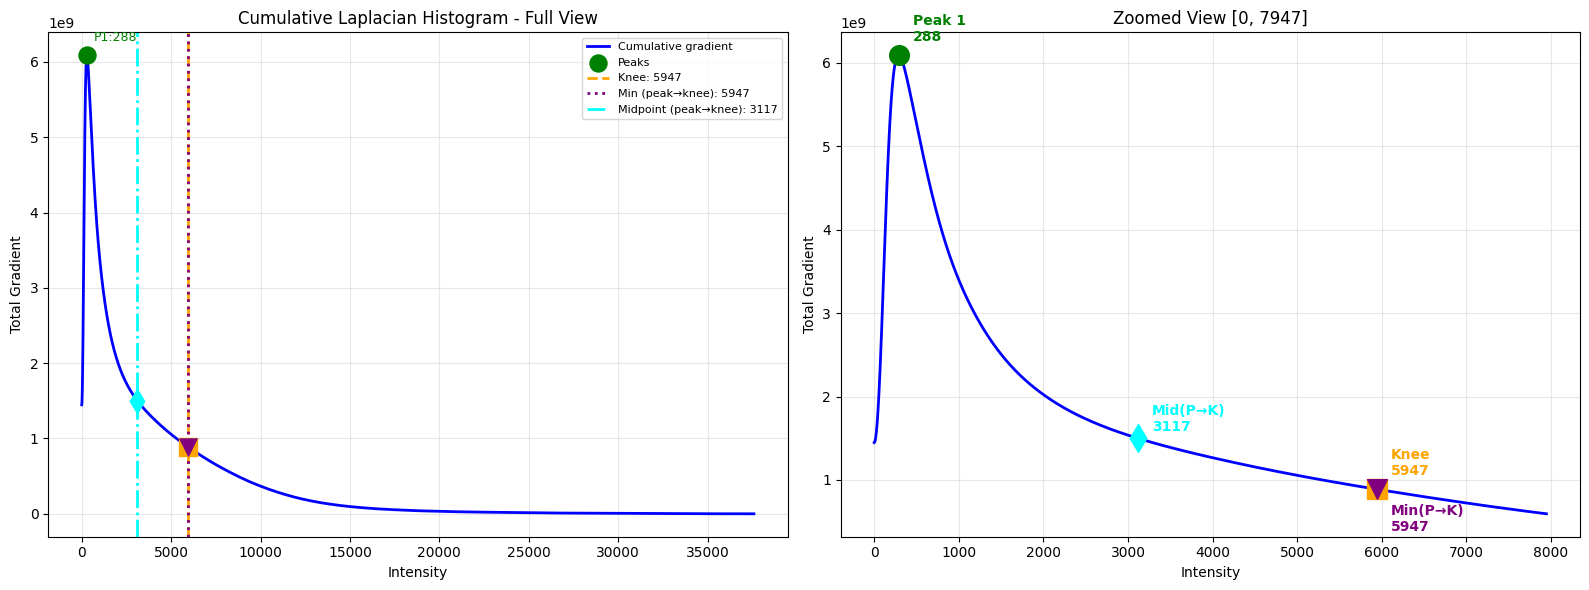


SUMMARY OF DETECTED THRESHOLDS
Feature                        Intensity      
---------------------------------------------
Peak 1                          288            
Min (last peak → knee)         5947           
Midpoint (last peak → knee)    3117           
Knee (after last peak)         5947           


In [46]:
import numpy as np
from scipy.ndimage import laplace, gaussian_filter1d
from scipy.signal import find_peaks
import tifffile
import matplotlib.pyplot as plt

# === LOAD DATA ===
input_path = "1_8064_9408_0_1344.tiff"
data = tifffile.imread(input_path)
print(f"Loaded: {data.shape}, dtype={data.dtype}")

data_float = data.astype(np.float64)

# === COMPUTE LAPLACIAN ===
laplacian = laplace(data_float)

# === BUILD CUMULATIVE HISTOGRAM ===
i_min, i_max = int(np.floor(data.min())), int(np.ceil(data.max()))
n_bins = i_max - i_min + 1

histogram = np.zeros(n_bins, dtype=np.float64)
intensities = data.ravel()
laplacian_values = laplacian.ravel()
bins = np.round(intensities).astype(np.int64) - i_min
np.add.at(histogram, bins, -laplacian_values)

cumulative = np.cumsum(histogram[::-1])[::-1]
x = np.arange(n_bins) + i_min

# === SMOOTH ===
sigma = max(3, n_bins // 500)
smoothed = gaussian_filter1d(cumulative, sigma=sigma)

# === FIND PEAKS ===
min_prominence = smoothed.max() * 0.005  # Lower threshold to catch more peaks
min_distance = max(10, n_bins // 200)

peaks, peak_props = find_peaks(
    smoothed, 
    prominence=min_prominence,
    distance=min_distance
)
peak_isovalues = x[peaks] if len(peaks) > 0 else np.array([])

# === FIND KNEE/SHOULDER POINT AFTER LAST PEAK ===
def find_knee_after_index(x_vals, y_vals, start_idx):
    """Find knee point on curve starting from start_idx."""
    x_sub = x_vals[start_idx:]
    y_sub = y_vals[start_idx:]
    
    if len(x_sub) < 10:
        return None, None
    
    x0, y0 = x_sub[0], y_sub[0]
    x1, y1 = x_sub[-1], y_sub[-1]
    dx, dy = x1 - x0, y1 - y0
    norm = np.sqrt(dx**2 + dy**2)
    
    if norm == 0:
        return None, None
    
    distances = np.abs(dy * x_sub - dx * y_sub + x1 * y0 - y1 * x0) / norm
    knee_idx_local = np.argmax(distances)
    knee_idx_global = start_idx + knee_idx_local
    return x_vals[knee_idx_global], knee_idx_global

# Find knee/shoulder after the last detected peak
if len(peaks) > 0:
    last_peak_idx = peaks[-1]
    knee_isovalue, knee_idx = find_knee_after_index(x, smoothed, last_peak_idx)
else:
    knee_isovalue, knee_idx = find_knee_after_index(x, smoothed, 0)

# === FIND MINIMA BETWEEN CONSECUTIVE PEAKS ===
def find_minima_between_peaks(curve, peaks, x_vals):
    """Find minimum between each pair of consecutive peaks."""
    if len(peaks) < 2:
        return np.array([], dtype=np.int64), np.array([])
    
    minima_indices = []
    minima_values = []
    
    for i in range(len(peaks) - 1):
        left = peaks[i]
        right = peaks[i + 1]
        region = curve[left:right + 1]
        local_min_idx = np.argmin(region)
        global_idx = left + local_min_idx
        minima_indices.append(global_idx)
        minima_values.append(curve[global_idx])
    
    return np.array(minima_indices, dtype=np.int64), np.array(minima_values)

minima_between_peaks_idx, minima_between_peaks_vals = find_minima_between_peaks(smoothed, peaks, x)
minima_between_peaks_isovalues = x[minima_between_peaks_idx] if len(minima_between_peaks_idx) > 0 else np.array([])

# === FIND MINIMUM AND MIDPOINT BETWEEN LAST PEAK AND KNEE ===
if len(peaks) > 0 and knee_idx is not None:
    last_peak_idx = peaks[-1]
    
    # Region between last peak and knee
    region_start = last_peak_idx
    region_end = knee_idx
    
    if region_end > region_start:
        region = smoothed[region_start:region_end + 1]
        
        # Minimum in this region
        local_min_idx = np.argmin(region)
        min_between_peak_knee_idx = region_start + local_min_idx
        min_between_peak_knee_isovalue = x[min_between_peak_knee_idx]
        min_between_peak_knee_value = smoothed[min_between_peak_knee_idx]
        
        # Midpoint (by index) between last peak and knee
        mid_idx = (region_start + region_end) // 2
        mid_isovalue = x[mid_idx]
        mid_value = smoothed[mid_idx]
    else:
        min_between_peak_knee_isovalue = None
        mid_isovalue = None
else:
    min_between_peak_knee_isovalue = None
    mid_isovalue = None

# === PRINT RESULTS ===
print(f"\n{'='*50}")
print("DETECTION RESULTS")
print(f"{'='*50}")

print(f"\n--- PEAKS ---")
if len(peak_isovalues) > 0:
    for i, pv in enumerate(peak_isovalues):
        print(f"  Peak {i+1}: intensity = {pv}")
else:
    print("  No peaks detected")

print(f"\n--- MINIMA BETWEEN CONSECUTIVE PEAKS ---")
if len(minima_between_peaks_isovalues) > 0:
    for i, mv in enumerate(minima_between_peaks_isovalues):
        print(f"  Minimum {i+1}: intensity = {mv} (between Peak {i+1} and Peak {i+2})")
else:
    print("  No minima between peaks (need at least 2 peaks)")

print(f"\n--- KNEE/SHOULDER AFTER LAST PEAK ---")
if knee_isovalue is not None:
    print(f"  Knee: intensity = {knee_isovalue}")
else:
    print("  No knee detected")

print(f"\n--- BETWEEN LAST PEAK AND KNEE ---")
if min_between_peak_knee_isovalue is not None:
    print(f"  Minimum: intensity = {min_between_peak_knee_isovalue}")
    print(f"  Midpoint: intensity = {mid_isovalue}")
else:
    print("  Could not compute (no peak or knee)")

# === PLOT ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Full view
ax1 = axes[0]
ax1.plot(x, smoothed, 'b-', linewidth=2, label='Cumulative gradient')

# Mark peaks (green)
if len(peaks) > 0:
    ax1.scatter(peak_isovalues, smoothed[peaks], color='green', s=150, zorder=5, marker='o', label='Peaks')
    for i, pv in enumerate(peak_isovalues):
        ax1.annotate(f'P{i+1}:{pv}', (pv, smoothed[peaks[i]]), 
                    textcoords="offset points", xytext=(5, 10), fontsize=9, color='green')

# Mark minima between peaks (red triangles)
if len(minima_between_peaks_idx) > 0:
    ax1.scatter(minima_between_peaks_isovalues, smoothed[minima_between_peaks_idx], 
               color='red', s=150, zorder=5, marker='v', label='Minima between peaks')
    for i, mv in enumerate(minima_between_peaks_isovalues):
        ax1.annotate(f'Min:{mv}', (mv, smoothed[minima_between_peaks_idx[i]]), 
                    textcoords="offset points", xytext=(5, -20), fontsize=9, color='red')

# Mark knee (orange)
if knee_isovalue is not None:
    ax1.axvline(knee_isovalue, color='orange', linestyle='--', linewidth=2, label=f'Knee: {knee_isovalue}')
    ax1.scatter([knee_isovalue], [smoothed[knee_idx]], color='orange', s=150, zorder=5, marker='s')

# Mark minimum between last peak and knee (purple)
if min_between_peak_knee_isovalue is not None:
    ax1.axvline(min_between_peak_knee_isovalue, color='purple', linestyle=':', linewidth=2, 
               label=f'Min (peak→knee): {min_between_peak_knee_isovalue}')
    ax1.scatter([min_between_peak_knee_isovalue], [min_between_peak_knee_value], 
               color='purple', s=150, zorder=5, marker='v')

# Mark midpoint between last peak and knee (cyan)
if mid_isovalue is not None:
    ax1.axvline(mid_isovalue, color='cyan', linestyle='-.', linewidth=2, 
               label=f'Midpoint (peak→knee): {mid_isovalue}')
    ax1.scatter([mid_isovalue], [mid_value], color='cyan', s=150, zorder=5, marker='d')

ax1.set_title("Cumulative Laplacian Histogram - Full View")
ax1.set_xlabel("Intensity")
ax1.set_ylabel("Total Gradient")
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Zoomed view
ax2 = axes[1]

# Determine zoom range
zoom_points = []
if len(peak_isovalues) > 0:
    zoom_points.extend(peak_isovalues.tolist())
if knee_isovalue is not None:
    zoom_points.append(knee_isovalue)
if min_between_peak_knee_isovalue is not None:
    zoom_points.append(min_between_peak_knee_isovalue)

if len(zoom_points) > 0:
    zoom_min = max(i_min, min(zoom_points) - 500)
    zoom_max = min(i_max, max(zoom_points) + 2000)
else:
    zoom_min, zoom_max = i_min, min(i_max, 10000)

mask = (x >= zoom_min) & (x <= zoom_max)
ax2.plot(x[mask], smoothed[mask], 'b-', linewidth=2)

# Same markers as above but in zoomed view
if len(peaks) > 0:
    for i, pv in enumerate(peak_isovalues):
        if zoom_min <= pv <= zoom_max:
            ax2.scatter([pv], [smoothed[peaks[i]]], color='green', s=200, zorder=5, marker='o')
            ax2.annotate(f'Peak {i+1}\n{pv}', (pv, smoothed[peaks[i]]), 
                        textcoords="offset points", xytext=(10, 10), fontsize=10, color='green',
                        fontweight='bold')

if len(minima_between_peaks_idx) > 0:
    for i, mv in enumerate(minima_between_peaks_isovalues):
        if zoom_min <= mv <= zoom_max:
            ax2.scatter([mv], [smoothed[minima_between_peaks_idx[i]]], color='red', s=200, zorder=5, marker='v')
            ax2.annotate(f'Min\n{mv}', (mv, smoothed[minima_between_peaks_idx[i]]), 
                        textcoords="offset points", xytext=(10, -30), fontsize=10, color='red',
                        fontweight='bold')

if knee_isovalue is not None and zoom_min <= knee_isovalue <= zoom_max:
    ax2.scatter([knee_isovalue], [smoothed[knee_idx]], color='orange', s=200, zorder=5, marker='s')
    ax2.annotate(f'Knee\n{knee_isovalue}', (knee_isovalue, smoothed[knee_idx]), 
                textcoords="offset points", xytext=(10, 10), fontsize=10, color='orange',
                fontweight='bold')

if min_between_peak_knee_isovalue is not None and zoom_min <= min_between_peak_knee_isovalue <= zoom_max:
    ax2.scatter([min_between_peak_knee_isovalue], [min_between_peak_knee_value], 
               color='purple', s=200, zorder=5, marker='v')
    ax2.annotate(f'Min(P→K)\n{min_between_peak_knee_isovalue}', 
                (min_between_peak_knee_isovalue, min_between_peak_knee_value), 
                textcoords="offset points", xytext=(10, -30), fontsize=10, color='purple',
                fontweight='bold')

if mid_isovalue is not None and zoom_min <= mid_isovalue <= zoom_max:
    ax2.scatter([mid_isovalue], [mid_value], color='cyan', s=200, zorder=5, marker='d')
    ax2.annotate(f'Mid(P→K)\n{mid_isovalue}', (mid_isovalue, mid_value), 
                textcoords="offset points", xytext=(10, 5), fontsize=10, color='cyan',
                fontweight='bold')

ax2.set_title(f"Zoomed View [{zoom_min}, {zoom_max}]")
ax2.set_xlabel("Intensity")
ax2.set_ylabel("Total Gradient")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("laplacian_analysis.png", dpi=150)
plt.show()

# === SUMMARY TABLE ===
print(f"\n{'='*50}")
print("SUMMARY OF DETECTED THRESHOLDS")
print(f"{'='*50}")
print(f"{'Feature':<30} {'Intensity':<15}")
print(f"{'-'*45}")

if len(peak_isovalues) > 0:
    for i, pv in enumerate(peak_isovalues):
        print(f"Peak {i+1:<26} {pv:<15}")

if len(minima_between_peaks_isovalues) > 0:
    for i, mv in enumerate(minima_between_peaks_isovalues):
        print(f"Min between Peak {i+1} & {i+2:<14} {mv:<15}")

if min_between_peak_knee_isovalue is not None:
    print(f"Min (last peak → knee)         {min_between_peak_knee_isovalue:<15}")

if mid_isovalue is not None:
    print(f"Midpoint (last peak → knee)    {mid_isovalue:<15}")

if knee_isovalue is not None:
    print(f"Knee (after last peak)         {knee_isovalue:<15}")

In [50]:
# === THRESHOLD AND SAVE ===
value = 288
mask = (data > value).astype(np.uint8) * 255

output_path = input_path.replace(".tiff", f"_knee_thresh_{value}.tiff")
tifffile.imwrite(output_path, mask, compression='zlib')

print(f"Threshold: {value}")
print(f"Active voxels: {np.sum(mask > 0):,} ({100 * np.sum(mask > 0) / mask.size:.2f}%)")
print(f"Saved: {output_path}")

Threshold: 288
Active voxels: 63,323,618 (18.07%)
Saved: 1_8064_9408_0_1344_knee_thresh_288.tiff


In [ ]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# Smooth slightly to avoid noise peaks
smoothed = gaussian_filter1d(cumulative, sigma=3)

# Find peaks with minimum prominence
peaks, properties = find_peaks(smoothed, prominence=smoothed.max() * 0.05)

print(f"Peaks at intensities: {peaks + i_min}")
print(f"Peak values: {smoothed[peaks]}")

# Often the SECOND peak is the meaningful one (first is background/noise)
if len(peaks) > 1:
    meaningful_threshold = peaks[1] + i_min
else:
    meaningful_threshold = peaks[0] + i_min

Knee intensity: 4400.5


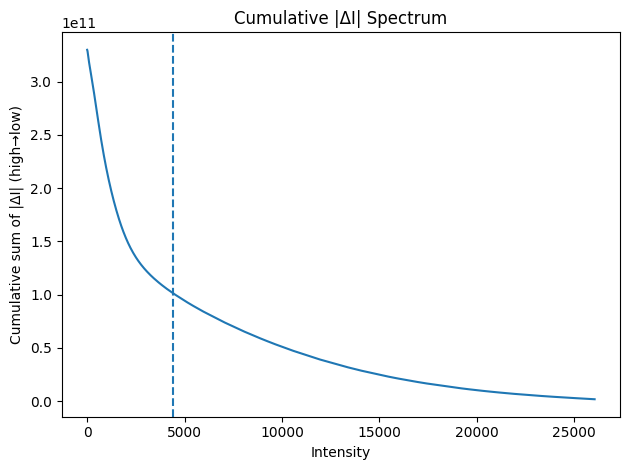

In [74]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace

def cumulative_abs_laplacian_spectrum(
    tiff_path: str,
    sigma: float = 1.0,
    bins: int | None = None,   # None => use exact integer bins if feasible
    robust_clip: tuple[float, float] | None = (0.0, 99.9),  # percentile clip for stability
):
    """
    Reads a TIFF (2D or 3D), computes |ΔI|, builds per-intensity histogram of |ΔI|,
    then cumulative-sums from high intensity to low, like Pekar-style accumulation.
    Returns (centers, cum_curve, knee_intensity).
    """
    I = tiff.imread(tiff_path)

    # Ensure float for derivatives
    I = I.astype(np.float32)

    # Optional robust clipping to reduce hot pixels / outliers
    if robust_clip is not None:
        lo, hi = np.percentile(I, robust_clip)
        I = np.clip(I, lo, hi)

    # Smooth (important for noisy microscopy)
    if sigma and sigma > 0:
        Is = gaussian_filter(I, sigma=sigma)
    else:
        Is = I

    # Laplacian and magnitude
    L = laplace(Is)           # signed
    A = np.abs(L)             # nonnegative "structure energy"

    # Decide binning strategy
    imin = float(np.min(I))
    imax = float(np.max(I))

    # If the data is near-integer and range is not insane, bin per integer value
    if bins is None:
        imin_i = int(np.floor(imin))
        imax_i = int(np.ceil(imax))
        rng = imax_i - imin_i + 1
        if rng <= 65536:  # safe-ish; adjust if you expect larger
            edges = np.arange(imin_i, imax_i + 2, dtype=np.float32)  # +2 for right edge
        else:
            bins = 4096  # fallback
    if bins is not None:
        edges = np.linspace(imin, imax, bins + 1, dtype=np.float32)

    # Histogram: weight each voxel by |ΔI| into its intensity bin
    hist, edges = np.histogram(I.ravel(), bins=edges, weights=A.ravel())

    # Cumulative from high intensity down (same direction as Pekar accumulation)
    cum = np.cumsum(hist[::-1])[::-1]

    # Bin centers for plotting
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Knee via max distance to chord between endpoints
    x = centers
    y = cum
    x0, y0 = x[0], y[0]
    x1, y1 = x[-1], y[-1]
    dx, dy = x1 - x0, y1 - y0
    norm = np.hypot(dx, dy) + 1e-12
    # Line distance formula
    d = np.abs(dy * x - dx * y + x1 * y0 - y1 * x0) / norm
    knee_idx = int(np.argmax(d))
    knee_val = float(x[knee_idx])

    return centers, cum, knee_val, (I, A)

def plot_spectrum(centers, cum, knee_val, title="Cumulative |ΔI| Spectrum"):
    plt.figure()
    plt.plot(centers, cum)
    plt.axvline(knee_val, linestyle="--")
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Cumulative sum of |ΔI| (high→low)")
    plt.tight_layout()
    plt.show()

import numpy as np
import tifffile as tiff

def threshold_and_save_mask(tiff_in, tiff_out, thr):
    I = tiff.imread(tiff_in)
    mask = (I >= thr).astype(np.uint8) * 255
    tiff.imwrite(tiff_out, mask)

def threshold_and_save_foreground(tiff_in, tiff_out, thr):
    I = tiff.imread(tiff_in)
    out = np.where(I >= thr, I, 0).astype(I.dtype)
    tiff.imwrite(tiff_out, out)


# ---- Example usage ----
if __name__ == "__main__":
    path = "0_8064_9408_0_1344.tiff"  # <-- change this
    centers, cum, knee_val, _ = cumulative_abs_laplacian_spectrum(
        path,
        sigma=0.1,          # try 0.5–2.0
        bins=None,          # per-integer bins if possible
        robust_clip=(0, 99.9),
    )
    print("Knee intensity:", knee_val)
    plot_spectrum(centers, cum, knee_val)
    threshold_and_save_mask(path, "mask_knee.tif", 933)


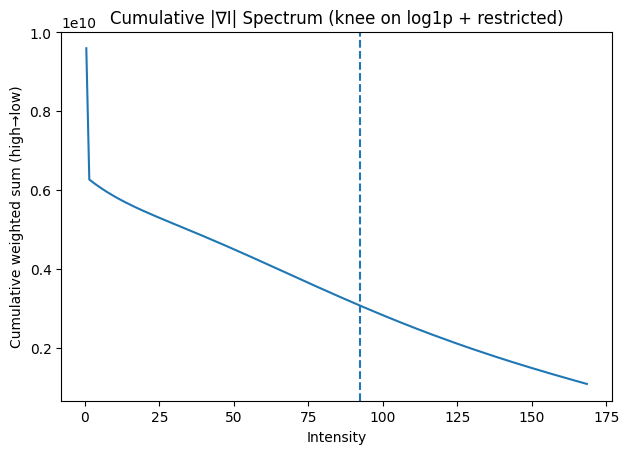

Threshold (knee, |∇I|): 92.5


In [124]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace, sobel

# ----------------------------
# Core spectra builders
# ----------------------------

def _build_weighted_cumulative_spectrum(I_float, W_float, bins=None):
    """
    Build weighted histogram over intensity, then cumulative-sum from high->low.
    I_float: float32 intensity image/volume
    W_float: float32 nonnegative weights (same shape)
    Returns centers, cum
    """
    imin = float(np.min(I_float))
    imax = float(np.max(I_float))

    # Choose bin edges
    if bins is None:
        imin_i = int(np.floor(imin))
        imax_i = int(np.ceil(imax))
        rng = imax_i - imin_i + 1
        if rng <= 65536:
            edges = np.arange(imin_i, imax_i + 2, dtype=np.float32)
        else:
            bins = 4096
    if bins is not None:
        edges = np.linspace(imin, imax, bins + 1, dtype=np.float32)

    hist, edges = np.histogram(I_float.ravel(), bins=edges, weights=W_float.ravel())
    cum = np.cumsum(hist[::-1])[::-1]
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, cum


def _knee_max_distance(centers, cum, use_logy=True, restrict=True, lo=0.05, hi=0.95):
    """
    Knee via max distance to chord. Options to make it match visual elbow better.
    - use_logy: operate on log1p(cum) to reduce tail dominance
    - restrict: search only where y is between [lo, hi] fraction of its range
    Returns (knee_idx, knee_val)
    """
    x = centers
    y = np.log1p(cum) if use_logy else cum

    if restrict:
        y_min, y_max = float(y.min()), float(y.max())
        y_lo = y_min + lo * (y_max - y_min)
        y_hi = y_min + hi * (y_max - y_min)
        mask = (y >= y_lo) & (y <= y_hi)
        idxs = np.where(mask)[0]
        if len(idxs) >= 3:
            i0, i1 = int(idxs[0]), int(idxs[-1])
            xs, ys = x[i0:i1 + 1], y[i0:i1 + 1]
            base = i0
        else:
            xs, ys = x, y
            base = 0
    else:
        xs, ys = x, y
        base = 0

    x0, y0 = float(xs[0]), float(ys[0])
    x1, y1 = float(xs[-1]), float(ys[-1])
    dx, dy = x1 - x0, y1 - y0
    norm = np.hypot(dx, dy) + 1e-12

    d = np.abs(dy * xs - dx * ys + x1 * y0 - y1 * x0) / norm
    knee_local = int(np.argmax(d))
    knee_idx = base + knee_local
    knee_val = float(x[knee_idx])
    return knee_idx, knee_val


# ----------------------------
# Option 1: |ΔI| spectrum (your current approach)
# ----------------------------
def cumulative_abs_laplacian_spectrum(
    tiff_path: str,
    sigma: float = 1.0,
    bins: int | None = None,
    robust_clip: tuple[float, float] | None = (0.0, 99.9),
    knee_logy: bool = True,
    knee_restrict: bool = True,
):
    I = tiff.imread(tiff_path).astype(np.float32)

    if robust_clip is not None:
        lo, hi = np.percentile(I, robust_clip)
        I = np.clip(I, lo, hi)

    Is = gaussian_filter(I, sigma=sigma) if (sigma and sigma > 0) else I
    L = laplace(Is)
    W = np.abs(L)  # nonnegative weights

    centers, cum = _build_weighted_cumulative_spectrum(I, W, bins=bins)
    _, knee_val = _knee_max_distance(centers, cum, use_logy=knee_logy, restrict=knee_restrict)
    return centers, cum, knee_val, (I, W)


# ----------------------------
# Option 2 (requested): |∇I| spectrum (often better behaved in microscopy)
# ----------------------------
def cumulative_gradmag_spectrum(
    tiff_path: str,
    sigma: float = 1.0,
    bins: int | None = None,
    robust_clip: tuple[float, float] | None = (0.0, 99.9),
    knee_logy: bool = True,
    knee_restrict: bool = True,
):
    """
    Reads TIFF (2D or 3D), computes gradient magnitude |∇I| (via Sobel),
    builds per-intensity weighted histogram of |∇I|, cumulative-sums high->low,
    then finds knee.
    """
    I = tiff.imread(tiff_path).astype(np.float32)

    if robust_clip is not None:
        lo, hi = np.percentile(I, robust_clip)
        I = np.clip(I, lo, hi)

    Is = gaussian_filter(I, sigma=sigma) if (sigma and sigma > 0) else I

    # Sobel per-axis. Works for both 2D and 3D.
    # If 2D: axes are (0,1). If 3D: axes are (0,1,2).
    gradsq = np.zeros_like(Is, dtype=np.float32)
    for ax in range(Is.ndim):
        g = sobel(Is, axis=ax, mode="nearest").astype(np.float32)
        gradsq += g * g
    W = np.sqrt(gradsq)  # |∇I|

    centers, cum = _build_weighted_cumulative_spectrum(I, W, bins=bins)
    _, knee_val = _knee_max_distance(centers, cum, use_logy=knee_logy, restrict=knee_restrict)
    return centers, cum, knee_val, (I, W)


# ----------------------------
# Plotting + thresholding helpers
# ----------------------------
def plot_spectrum(centers, cum, thr, title="Cumulative Spectrum"):
    plt.figure()
    plt.plot(centers, cum)
    plt.axvline(thr, linestyle="--")
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Cumulative weighted sum (high→low)")
    plt.tight_layout()
    plt.show()


def threshold_and_save_mask(tiff_in, tiff_out, thr):
    I = tiff.imread(tiff_in)
    mask = (I >= thr).astype(np.uint8) * 255
    tiff.imwrite(tiff_out, mask)


def threshold_and_save_foreground(tiff_in, tiff_out, thr):
    I = tiff.imread(tiff_in)
    out = np.where(I >= thr, I, 0).astype(I.dtype)
    tiff.imwrite(tiff_out, out)

import numpy as np
from scipy import ndimage

def remove_small_components_3d(
    mask: np.ndarray,
    spacing_um=(0.28, 0.14, 0.14),   # (z, y, x)
    min_volume_um3: float = 0.1,     # default ~0.1 µm³ (tune)
    connectivity: int = 26,          # 6, 18, or 26
    return_labels: bool = False,
):
    """
    Remove disjoint 3D connected components smaller than min_volume_um3.
    
    mask: bool or 0/1 ndarray, shape (Z,Y,X)
    spacing_um: voxel spacing (z,y,x) in micrometers
    min_volume_um3: minimum physical volume to keep (µm³)
    connectivity: 6/18/26 neighborhood
    return_labels: optionally return the labeled volume and stats
    """
    if mask.ndim != 3:
        raise ValueError(f"mask must be 3D (Z,Y,X); got shape {mask.shape}")

    mask = mask.astype(bool)

    # Pick connectivity structure
    if connectivity == 6:
        structure = ndimage.generate_binary_structure(3, 1)  # faces only
    elif connectivity == 18:
        structure = ndimage.generate_binary_structure(3, 2)  # faces+edges
        # Note: SciPy's rank=2 gives 18-connect in 3D
    elif connectivity == 26:
        structure = np.ones((3, 3, 3), dtype=bool)          # faces+edges+corners
    else:
        raise ValueError("connectivity must be one of {6, 18, 26}")

    # Label components
    labels, num = ndimage.label(mask, structure=structure)
    if num == 0:
        return (mask, labels, {}) if return_labels else mask

    # Count voxels per component (label 0 is background)
    counts = np.bincount(labels.ravel())
    # Physical volume per voxel
    voxel_vol = float(spacing_um[0] * spacing_um[1] * spacing_um[2])
    volumes_um3 = counts * voxel_vol

    # Determine which labels to keep
    keep = volumes_um3 >= float(min_volume_um3)
    keep[0] = False  # background

    # Filter mask by keeping only big labels
    cleaned = keep[labels]

    if return_labels:
        stats = {
            "num_components": int(num),
            "voxel_volume_um3": voxel_vol,
            "min_volume_um3": float(min_volume_um3),
            "kept_components": int(np.sum(keep)),
            "component_counts_vox": counts,
            "component_volumes_um3": volumes_um3,
        }
        return cleaned, labels, stats

    return cleaned

# ----------------------------
# Example usage
# ----------------------------
if __name__ == "__main__":
    path = "7_8064_9408_0_1344.tiff"

    # --- Choose ONE approach ---

    # A) |ΔI| (abs Laplacian) spectrum
    centers, cum, thr, _ = cumulative_abs_laplacian_spectrum(
        path,
        sigma=0.1,
        bins=None,
        robust_clip=(0.,97.5),
        knee_logy=False,        # helps knee match visual elbow
        knee_restrict=True,    # ignores far tail
    )
    # plot_spectrum(centers, cum, thr, title="Cumulative |ΔI| Spectrum (knee on log1p + restricted)")
    # print("Threshold (knee):", thr)

    # B) |∇I| (gradient magnitude) spectrum  <-- requested alternative
    # centers_g, cum_g, thr_g, _ = cumulative_gradmag_spectrum(
    #     path,
    #     sigma=1.0,             # gradient mag usually likes a bit more smoothing
    #     bins=None,
    #     robust_clip=(0, 99.9),
    #     knee_logy=False,
    #     knee_restrict=False,
    # )
    plot_spectrum(centers, cum, thr, title="Cumulative |∇I| Spectrum (knee on log1p + restricted)")
    print("Threshold (knee, |∇I|):", thr)

    # --- Save thresholded outputs (pick thr or thr_g) ---
    threshold_and_save_mask(path, "mask_knee.tif", thr)
    I = tiff.imread(path)

    # 1) threshold mask
    mask = (I >= thr)

    # threshold_and_save_foreground(path, "foreground_knee.tif", thr_g)
    clean = remove_small_components_3d(
    mask,
    spacing_um=(0.28, 0.14, 0.14),
    min_volume_um3=0.8,     # tune this
    connectivity=26,
    )
    tiff.imwrite("mask_cleaned.tif", (clean.astype(np.uint8) * 255))

In [ ]:
centers, cum, thr, _ = cumulative_abs_laplacian_spectrum(
        path,
        sigma=0.1,
        bins=None,
        robust_clip=(0.,97.5),
        knee_logy=False,        # helps knee match visual elbow
        knee_restrict=True,    # ignores far tail
    )

Elbow intensity: 20683.5


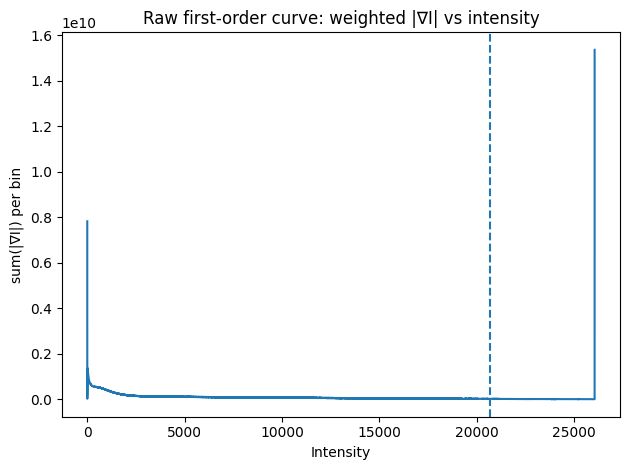

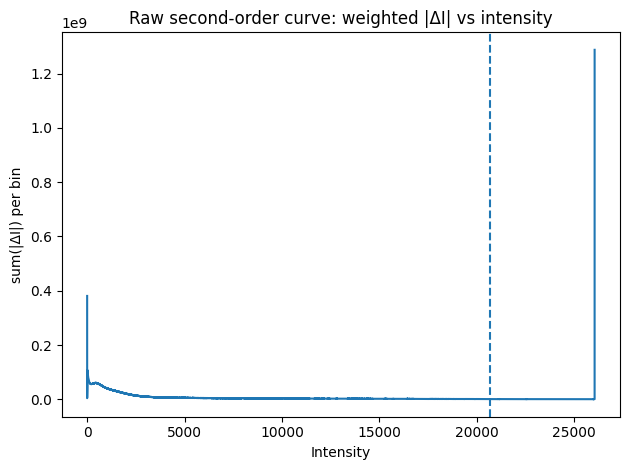

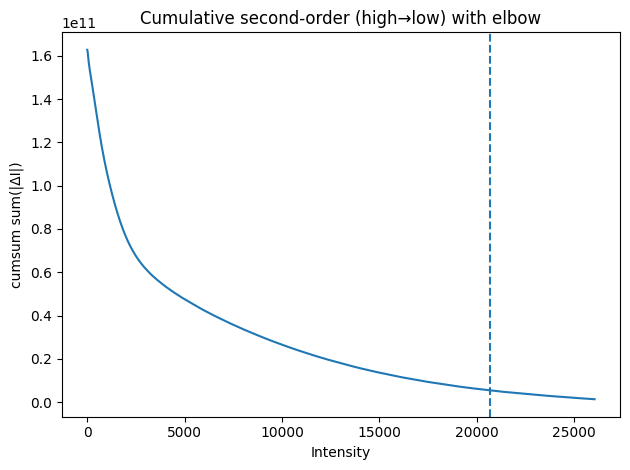

Saved: mask_elbow.tif


In [126]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, sobel, laplace

# ---- edit these ----
path = "0_8064_9408_0_1344.tiff"      # 2D or 3D TIFF
sigma = 0.5                  # try 0.0, 0.4, 0.8 (derivatives get cleaner as sigma increases)
robust_clip = (0.0, 99.9)    # set None to disable
bins = None                  # None => per-integer bins if range <= 65536, else 4096
out_mask = "mask_elbow.tif"

# ---- read + prep ----
I0 = tiff.imread(path)
I = I0.astype(np.float32)

if robust_clip is not None:
    lo, hi = np.percentile(I, robust_clip)
    I = np.clip(I, lo, hi)

Is = gaussian_filter(I, sigma=sigma) if sigma and sigma > 0 else I

# ---- 1) first-order derivative magnitude |∇I| ----
gradsq = np.zeros_like(Is, dtype=np.float32)
for ax in range(Is.ndim):
    g = sobel(Is, axis=ax, mode="nearest").astype(np.float32)
    gradsq += g*g
G = np.sqrt(gradsq)

# ---- 2) second-order derivative magnitude |ΔI| ----
L = laplace(Is).astype(np.float32)
A = np.abs(L)

# ---- histogram bins over intensity ----
imin, imax = float(I.min()), float(I.max())
if bins is None:
    imin_i, imax_i = int(np.floor(imin)), int(np.ceil(imax))
    rng = imax_i - imin_i + 1
    if rng <= 65536:
        edges = np.arange(imin_i, imax_i + 2, dtype=np.float32)
    else:
        edges = np.linspace(imin, imax, 4096 + 1, dtype=np.float32)
else:
    edges = np.linspace(imin, imax, bins + 1, dtype=np.float32)

centers = 0.5 * (edges[:-1] + edges[1:])

# Raw (non-cumulative) weighted derivative curves:
h1, _ = np.histogram(I.ravel(), bins=edges, weights=G.ravel())  # |∇I| vs intensity
h2, _ = np.histogram(I.ravel(), bins=edges, weights=A.ravel())  # |ΔI| vs intensity

# Cumulative (high->low) for elbow detection (using |ΔI|; swap to h1 if you prefer):
cum = np.cumsum(h2[::-1])[::-1]

# ---- 3) elbow intensity (max distance to chord on log-cum) ----
x = centers
y = np.log1p(cum)  # makes elbow match visual better
x0, y0 = float(x[0]), float(y[0])
x1, y1 = float(x[-1]), float(y[-1])
dx, dy = x1 - x0, y1 - y0
norm = np.hypot(dx, dy) + 1e-12
d = np.abs(dy * x - dx * y + x1 * y0 - y1 * x0) / norm
elbow_idx = int(np.argmax(d))
elbow_val = float(x[elbow_idx])
print("Elbow intensity:", elbow_val)

# ---- plots ----
plt.figure(); plt.plot(centers, h1); plt.title("Raw first-order curve: weighted |∇I| vs intensity")
plt.xlabel("Intensity"); plt.ylabel("sum(|∇I|) per bin"); plt.axvline(elbow_val, linestyle="--"); plt.tight_layout(); plt.show()

plt.figure(); plt.plot(centers, h2); plt.title("Raw second-order curve: weighted |ΔI| vs intensity")
plt.xlabel("Intensity"); plt.ylabel("sum(|ΔI|) per bin"); plt.axvline(elbow_val, linestyle="--"); plt.tight_layout(); plt.show()

plt.figure(); plt.plot(centers, cum); plt.title("Cumulative second-order (high→low) with elbow")
plt.xlabel("Intensity"); plt.ylabel("cumsum sum(|ΔI|)"); plt.axvline(elbow_val, linestyle="--"); plt.tight_layout(); plt.show()

# ---- 4) threshold + save ----
def threshold_and_save_mask(tiff_in, tiff_out, thr, as_255=True):
    J = tiff.imread(tiff_in)
    m = (J >= thr)
    if as_255:
        tiff.imwrite(tiff_out, (m.astype(np.uint8) * 255))
    else:
        tiff.imwrite(tiff_out, m.astype(np.uint8))
    return m

_ = threshold_and_save_mask(path, out_mask, elbow_val, as_255=True)
print("Saved:", out_mask)
